# 🧪 AWS Architecture - Batch Prompt Evaluation & Ablation Lab

Este notebook implementa el entorno profesional de **Evaluación Incremental de Prompts** (*Reverse Ablation Study*) para medir el impacto real de cada regla nueva en la extracción de arquitecturas con la API de Gemini (Stage 1: World Model + Stage 2: Final Graph).

--- 
### 1. Metodología: ¿Cómo se evalúan prompts profesionalmente con API limitada?
En la industria se usan plataformas como Promptfoo, LangSmith o Weights & Biases (W&B). En este laboratorio con un dataset cerrado de **14 videos de Cloudscape Reports** y cuotas de API activas, aplicamos el enfoque acumulativo:

1. **Baseline (V0):** El prompt estándar parsimonioso base (resultados de referencia).
2. **Version 1 (V1):** Baseline + Regla 1 (*Filtro de Monitoreo / Logging en segundo plano*).
3. **Version 2 (V2):** V1 + Regla 2 (*Filtro de Ejemplos Verbales / Alternativas Hipotéticas*).
4. **Version 3 (V3):** V2 + Regla 3 (*Prioridad de Texto Nominal sobre Visión*).

### 📊 Gráficas Automáticas Incluidas:
- **Bar Chart de Progreso Promedio:** Muestra la evolución global del `Service F1` y `Edge F1` por versión.
- **Boxplot (Diagrama de Cajas):** Muestra la reducción de varianza y la consistencia del modelo evitando errores atípicos.
- **Heatmap (Delta Celda a Celda):** Matriz visual de 14 videos x Versiones con deltas en verde (mejora) o rojo (regresión), identificando exactamente si una regla rompió un video en particular.

## 📌 Paso 1: Importaciones y Configuración del Entorno

In [2]:
import os
import sys
import json
import csv
import shutil
import time
import base64
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Configuración de rutas del proyecto
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "whiteboard_selection_lab":
    LAB_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    LAB_DIR = PROJECT_ROOT / "whiteboard_selection_lab"

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(LAB_DIR / "algorithms"))

from config.settings import GEMINI_API_KEY, GEMINI_MODEL
from scripts.core.graph_builder import create_graph_from_cloudscape_json, export_graphml
from scripts.utils.evaluate_graphs import evaluate_pair, load_services_catalog

try:
    from algorithms.adaptive_whiteboard_detector import (
        procesar_y_resaltar_conclusiones_pizarra,
        format_symbols_for_prompt,
    )
    HAS_DETECTOR = True
except ImportError:
    HAS_DETECTOR = False

# Directorios de datos
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
GOOD_WHITEBOARD_DIR = DATA_DIR / "good_whiteboard"
GT_DIR = DATA_DIR / "cloudscape_gt"
SERVICES_CSV = GT_DIR / "services.csv" if (GT_DIR / "services.csv").exists() else DATA_DIR / "services.csv"
REPORTS_DIR = PROJECT_ROOT / "cloudscape_reports"
LAB_WORKSPACE = LAB_DIR / "lab_workspace"
TRANSCRIPTIONS_DIR = LAB_DIR / "transcriptions"

print("✓ Entorno inicializado con éxito.")
print(f"  • Raíz del proyecto: {PROJECT_ROOT}")
print(f"  • Directorio de laboratorio: {LAB_DIR}")
print(f"  • Gemini API Key configurada: {'Sí' if GEMINI_API_KEY else 'No'}")

✓ Entorno inicializado con éxito.
  • Raíz del proyecto: /home/stemjara/Projects/AWS-Architecture
  • Directorio de laboratorio: /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab
  • Gemini API Key configurada: Sí


## ⚙️ Paso 2: Panel de Control del Experimento (Configuración Fácil)
Modifica las variables en esta celda para ajustar el modelo, nombre del experimento, forzar re-ejecuciones o seleccionar la lista de videos.

In [3]:
# ==============================================================================
# ⚙️ CONFIGURACIÓN DE EXPERIMENTO (MODIFICA AQUÍ TUS PARÁMETROS)
# ==============================================================================

# 1. Nombre / Versión del Modelo de Gemini
# Puedes probar 'gemini-3.5-flash', 'gemini-2.5-flash', etc.
MODEL_NAME = 'gemini-3.5-flash'

# 2. Etiqueta del Experimento / Versión a Probar
# Cambia esta etiqueta para cada versión que pruebes: 'v1_monitoring', 'v2_verbal', 'v3_text_priority'
EXPERIMENT_LABEL = "v1_stage2_strict"

# 3. Forzar Re-ejecución (True: Llama de nuevo a Gemini API / False: Reusa caché local json si existe)
FORCE_RERUN = False

# 4. Dataset de 14 Videos de Cloudscape Reports
ALL_14_VIDEOS = [
    "-3lnf5lzsH0", "-kA0ahrhX3I", "-wLEkq21cvA", "07lfvavMdfU", "1aYoIZvabbk",
    "2L0m28ZLmtE", "2e3vOxsHekE", "6CgqEzyWpeA", "6EUknQqaV1w", "6YkguepAQuQ",
    "BZ32w0SSAoY", "Cgv0kfp_6xQ", "wjtSHyENv0I", "ww5fiygF6eg"
]

# Puedes filtrar la lista a solo un par de videos si quieres probar rápido (ej: ALL_14_VIDEOS[:2])
VIDEO_IDS = ALL_14_VIDEOS

# 5. Ruta de guardado del resumen batch
OUTPUT_SUMMARY_FILE = LAB_DIR / f"batch_results_{EXPERIMENT_LABEL}.json"

print("📋 EXPERIMENTO CONFIGURADO:")
print(f"   • Modelo: {MODEL_NAME}")
print(f"   • Etiqueta: {EXPERIMENT_LABEL}")
print(f"   • Force Re-run: {FORCE_RERUN}")
print(f"   • Cantidad de videos: {len(VIDEO_IDS)}")
print(f"   • Archivo de salida: {OUTPUT_SUMMARY_FILE.name}")

📋 EXPERIMENTO CONFIGURADO:
   • Modelo: gemini-3.5-flash
   • Etiqueta: v1_stage2_strict
   • Force Re-run: False
   • Cantidad de videos: 14
   • Archivo de salida: batch_results_v1_stage2_strict.json


## 📝 Paso 3: Definición Modular de Prompts (Stage 1 & Stage 2)
Aquí se estructuran las versiones de los prompts de forma limpia. Selecciona la versión activa cambiando `ACTIVE_STAGE1_PROMPT` y `ACTIVE_STAGE2_PROMPT`.

In [12]:
# ==============================================================================
# STAGE 1: WORLD MODEL PROMPT VERSIONS
# ==============================================================================

STAGE1_V0_BASELINE = """You are an expert in visual extraction of cloud architectures. Your task is to analyze the provided whiteboard diagram and audio transcript to build a structured "World Model" representing the components and their visual groupings.

Do NOT generate the final graph. Focus strictly on identifying the present entities, how they are visually grouped, and what lines connect them.

## ENTITY IDENTIFICATION AND GROUPING RULES:
1. Identify all active systems, databases, cloud services, and actors VISIBLE on the whiteboard.
2. Identify BOXES or dashed containers. If a service (e.g., SAP) is drawn inside another service or box (e.g., EC2), register both and strictly note this containment in the "rationale".
3. Use valid AWS services from this list: <AWS_SERVICES_PLACEHOLDER>.
4. Identify actors/users from this list: <USER_ACTORS_PLACEHOLDER>. Map on-premises/external systems to "ThirdParty" and actors to "User".
5. Do NOT include transient files, packages, or disk images (like AMIs) as entities.

## VISUAL CONNECTION RULES:
1. Register ALL lines or arrows explicitly drawn between entities on the whiteboard.
2. Note the source, target, and the direction of the arrow.
"""

# Versión 1: Baseline + Regla 1 (Filtro de Monitoreo/Logs en segundo plano)
STAGE1_V1_MONITORING = STAGE1_V0_BASELINE + """
## MONITORING AND BACKGROUND LOGGING FILTER (RULE V1):
- Do NOT extract background logging, metrics collectors, or monitoring agents (e.g., CloudWatch Logs agent, CloudTrail background auditing) as standalone node entities unless they are explicitly drawn as distinct visual service icons on the whiteboard.
"""

# Versión 2: V1 + Regla 2 (Filtro de Ejemplos Verbales / Alternativas Hipotéticas)
STAGE1_V2_VERBAL_EXAMPLES = STAGE1_V1_MONITORING + """
## HYPOTHETICAL / VERBAL EXAMPLES FILTER (RULE V2):
- Do NOT create entities for services mentioned verbally in the audio purely as hypothetical options or future migration ideas (e.g., 'we could also use DynamoDB'). Only extract services that form part of the actual active architecture.
"""

# Versión 3: V2 + Regla 3 (Prioridad de Texto Nominal sobre Visión)
STAGE1_V3_TEXT_PRIORITY = STAGE1_V2_VERBAL_EXAMPLES + """
## CONTROLLED TEXT-OVER-VISION NAME PRIORITY (RULE V3):
- If an icon drawn on the whiteboard has a generic shape, but the speaker explicitly names the canonical AWS service in the transcript (e.g., icon drawn as generic DB, speaker says 'Aurora MySQL'), map the service name to the explicit canonical service.
"""

# 👈 SELECCIONA AQUÍ TU STAGE 1 PROMPT ACTIVO
ACTIVE_STAGE1_PROMPT = STAGE1_V0_BASELINE
print("✓ Prompt de Stage 1 (World Model) asignado.")

✓ Prompt de Stage 1 (World Model) asignado.


In [13]:
# ==============================================================================
# STAGE 2: FINAL ARCHITECTURE GRAPH PROMPT VERSIONS
# ==============================================================================

STAGE2_V0_BASELINE = """You are an expert AWS Solutions Architect. Your task is to compile the final logical cloud architecture graph from the provided World Model and audio transcript.

You must generalize your reasoning to deduce the true logical "Ground Truth" architecture based on standard AWS patterns.

## VALID VOCABULARY LISTS (CRITICAL):
You may ONLY use exact values from these lists for the "service" field.

AWS Services:
<AWS_SERVICES_PLACEHOLDER>

User and Client Actors:
<USER_ACTORS_PLACEHOLDER>

## MULTILINGUAL TRANSLATION RULE:
Translate all output text fields (notes, graph name, reasoning, etc.) into ENGLISH.

## WORLD MODEL (BASE INPUT):
Use this as your visual inventory.
<WORLD_MODEL_PLACEHOLDER>

## NODE RULES (PRUNING, FUSION, AND AUDIO-DRIVEN EXPANSION):
1. **Strict Normalization (CRITICAL):** The "service" field MUST match exactly with an element from the VALID VOCABULARY LISTS.
2. **Numeric Identifiers:** The "id" field of each node MUST be strictly a sequential integer in string format (e.g., "0", "1", "2").
3. **Audio-Driven Expansion (CRITICAL OVERRIDE):** If the visual World Model shows a generic abstraction (e.g., a single "AWS" cloud icon, or "On-Prem"), but the audio transcript explicitly lists specific services belonging to that group (e.g., S3, SNS, SQS, CloudTrail, GuardDuty), you MUST expand the generic visual node into separate, individual nodes for each explicitly mentioned service. DO NOT create the generic parent node; only create its specific children and route them to their logical destination.
4. **Dynamic Logical Fusion:** Evaluate multiple icons of the same service dynamically. If they act as a single logical unit, FUSE them. If they perform distinct architectural steps at different stages, KEEP THEM SEPARATE.
5. **Pruning:** Remove generic human actors or purely physical concepts. Keep system entry points.
6. **Note Assimilation:** Extract specific constraints and metrics from the transcript and inject them into the "notes".

## EDGE AND FLOW RULES (LOGICAL ROUTING):
1. **Strict Flow Segmentation (`flow_id`):** Group related architectural actions into distinct logical workflows using an integer `flow_id` (starting at 0).
2. **Chronological Sequence (`seq`):** Order events within a flow using string integers ("0", "1"). Use the prime character for parallel actions (e.g., "1" and "1'"). Model bidirectionality as two edges.
3. **Edge Types (`type`):** Use "data" for payload transfers/reads/writes. Use "control" for events, triggers, or asynchronous invocations.
"""

# ------------------------------------------------------------------------------
# 1. Definimos las reglas tóxicas que queremos "quitar" del baseline
# ------------------------------------------------------------------------------
TOXIC_INTRO = 'You must generalize your reasoning to deduce the true logical "Ground Truth" architecture based on standard AWS patterns.'

TOXIC_RULE_3 = '3. **Audio-Driven Expansion (CRITICAL OVERRIDE):** If the visual World Model shows a generic abstraction (e.g., a single "AWS" cloud icon, or "On-Prem"), but the audio transcript explicitly lists specific services belonging to that group (e.g., S3, SNS, SQS, CloudTrail, GuardDuty), you MUST expand the generic visual node into separate, individual nodes for each explicitly mentioned service. DO NOT create the generic parent node; only create its specific children and route them to their logical destination.'

# ------------------------------------------------------------------------------
# Versión 1: Stage 2 + Literalidad (Reemplazando lo malo por reglas de conservación)
# ------------------------------------------------------------------------------
STAGE2_V1_STRICT_CONSERVATION = STAGE2_V0_BASELINE.replace(
    TOXIC_INTRO, 
    'CRITICAL: Do NOT "over-architect" or invent connections based on generic AWS best practices. You must strictly respect the entities and topology provided by the World Model.'
).replace(
    TOXIC_RULE_3, 
    '3. **Strict Node Conservation (CRITICAL OVERRIDE):** You MUST use ONLY the exact entities provided in the World Model. DO NOT introduce new AWS services just because they represent AWS best practices or were vaguely implied in the audio.'
) + """
## EDGE FLOW PRUNING (RULE V1):
- Strict Edge Literalism: Base your edges STRICTLY on the visual connections from the World Model. DO NOT invent new edges (e.g., return arrows for notifications, Slack alerts, or monitoring paths) that are not present visually.
- No Implicit Database Reads: DO NOT draw an edge out of a database (e.g., DynamoDB, S3) just because a compute service logically needs to read from it.
"""

# ------------------------------------------------------------------------------
# Versión 2: V1 + Filtro de Ejemplos Verbales
# ------------------------------------------------------------------------------
STAGE2_V2_VERBAL_EXAMPLES = STAGE2_V1_STRICT_CONSERVATION + """
## VERBAL EDGE PRUNING (RULE V2):
- Do not generate edges to nodes pruned as hypothetical options.
"""

# ------------------------------------------------------------------------------
# Versión 3: V2 + Estricta Normalización
# ------------------------------------------------------------------------------
STAGE2_V3_TEXT_PRIORITY = STAGE2_V2_VERBAL_EXAMPLES + """
## STRICT SERVICE NAME NORMALIZATION (RULE V3):
- Ensure that every single node service field strictly maps to canonical catalog items.
"""

# 👈 SELECCIONA AQUÍ TU STAGE 2 PROMPT ACTIVO
ACTIVE_STAGE2_PROMPT = STAGE2_V1_STRICT_CONSERVATION
print("✓ Prompt de Stage 2 (Final Graph) asignado.")

✓ Prompt de Stage 2 (Final Graph) asignado.


## 🚀 Paso 4: Motor de Procesamiento Batch
Definición de funciones para ejecutar el pipeline de Gemini, evaluar contra Ground Truth y registrar los resultados.

In [14]:
from google import genai

_client = None

def get_gemini_client():
    global _client
    if _client is None:
        if not GEMINI_API_KEY:
            raise ValueError("GEMINI_API_KEY no encontrada en .env")
        _client = genai.Client(api_key=GEMINI_API_KEY)
    return _client

def load_services_catalogs():
    aws_services, user_actors = set(), set()
    catalog_dict = {}
    if SERVICES_CSV.exists():
        with open(SERVICES_CSV, mode="r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                name = row.get("name", "").strip()
                capability = row.get("capability", "").strip().lower()
                if not name:
                    continue
                catalog_dict[name] = {"capability": capability}
                if capability == "user" or name.startswith("User"):
                    user_actors.add(name)
                else:
                    aws_services.add(name)
    return ", ".join(sorted(aws_services)), ", ".join(sorted(user_actors)), catalog_dict

AWS_SERVICES_STR, USER_ACTORS_STR, CATALOG_DICT = load_services_catalogs()

def call_gemini_api(full_prompt, mime, image_b64, model_name):
    client = get_gemini_client()
    max_retries = 5
    retry_delay = 10
    config = {"response_mime_type": "application/json"}
    
    for attempt in range(max_retries):
        try:
            res = client.models.generate_content(
                model=model_name,
                contents=[{
                    "parts": [
                        {"text": full_prompt},
                        {"inline_data": {"mime_type": mime, "data": image_b64}}
                    ]
                }],
                config=config,
            )
            return json.loads(res.text)
        except Exception as e:
            err_msg = str(e).upper()
            if attempt < max_retries - 1 and any(k in err_msg for k in ["503", "429", "RESOURCE_EXHAUSTED", "LIMIT"]):
                delay = 35 if ("429" in err_msg or "RESOURCE" in err_msg) else retry_delay
                print(f"  ⚠ API Limit/Error ({e}). Esperando {delay}s (intento {attempt+1}/{max_retries})...")
                time.sleep(delay)
                retry_delay *= 2
            else:
                raise e

def process_single_video_eval(video_id, stage1_tmpl, stage2_tmpl, exp_label, model_name, force):
    workspace = LAB_WORKSPACE / video_id
    workspace.mkdir(parents=True, exist_ok=True)
    
    local_wb = workspace / "best_whiteboard.jpg"
    wb_src = GOOD_WHITEBOARD_DIR / f"{video_id}.jpg"
    if not wb_src.exists():
        return {"video_id": video_id, "status": "error", "error": "No whiteboard in good_whiteboard/"}
    if not local_wb.exists() or force:
        shutil.copy2(wb_src, local_wb)
        
    t_src = RAW_DIR / f"{video_id}_transcript.json"
    t_lab = TRANSCRIPTIONS_DIR / f"{video_id}_transcript.json"
    if t_src.exists() and (not t_lab.exists() or force):
        TRANSCRIPTIONS_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(t_src, t_lab)
        
    transcript_text = ""
    target_t = t_lab if t_lab.exists() else t_src
    if target_t.exists():
        with open(target_t, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, list):
                transcript_text = " ".join(s.get("text", "").strip() for s in data)
            elif isinstance(data, dict):
                transcript_text = data.get("text", "")
                
    img_b64 = base64.b64encode(local_wb.read_bytes()).decode("utf-8")
    
    suffix = f"_{exp_label}" if exp_label else ""
    wm_path = workspace / f"world_model{suffix}.json"
    an_path = workspace / f"test_analysis{suffix}.json"
    gml_path = workspace / f"test_graph{suffix}.graphml"
    eval_path = workspace / f"evaluation{suffix}.json"
    
    symbols_prompt = ""
    if HAS_DETECTOR:
        try:
            syms, _ = procesar_y_resaltar_conclusiones_pizarra(local_wb, workspace, delta_contraste_min=40.0)
            symbols_prompt = format_symbols_for_prompt(syms)
        except Exception:
            pass

    # Stage 1: Priorizar la caché del World Model BASE (V0 Baseline)
    wm_base = workspace / "world_model.json"
    if wm_base.exists() and not force:
        with open(wm_base, "r", encoding="utf-8") as f:
            world_model = json.load(f)
    elif wm_path.exists() and not force:
        with open(wm_path, "r", encoding="utf-8") as f:
            world_model = json.load(f)
    else:
        p1 = stage1_tmpl.replace("<AWS_SERVICES_PLACEHOLDER>", AWS_SERVICES_STR).replace("<USER_ACTORS_PLACEHOLDER>", USER_ACTORS_STR)
        parts1 = [p1]
        if symbols_prompt: parts1.append(symbols_prompt)
        parts1.append(f"\n## VIDEO URL:\nhttps://www.youtube.com/watch?v={video_id}")
        if transcript_text: parts1.append(f"\n## FULL TRANSCRIPT:\n{transcript_text}")
        world_model = call_gemini_api("\n".join(parts1), "image/jpeg", img_b64, model_name)
        with open(wm_path, "w", encoding="utf-8") as f:
            json.dump(world_model, f, indent=2, ensure_ascii=False)
            
    # Stage 2
    if an_path.exists() and not force:
        with open(an_path, "r", encoding="utf-8") as f:
            analysis_res = json.load(f)
    else:
        p2 = stage2_tmpl.replace("<WORLD_MODEL_PLACEHOLDER>", json.dumps(world_model, indent=2, ensure_ascii=False)) \
                        .replace("<AWS_SERVICES_PLACEHOLDER>", AWS_SERVICES_STR) \
                        .replace("<USER_ACTORS_PLACEHOLDER>", USER_ACTORS_STR)
        parts2 = [p2, f"\n## VIDEO URL:\nhttps://www.youtube.com/watch?v={video_id}"]
        if transcript_text: parts2.append(f"\n## FULL TRANSCRIPT:\n{transcript_text}")
        analysis_res = call_gemini_api("\n".join(parts2), "image/jpeg", img_b64, model_name)
        with open(an_path, "w", encoding="utf-8") as f:
            json.dump(analysis_res, f, indent=2, ensure_ascii=False)
            
    G = create_graph_from_cloudscape_json(analysis_res, video_id=video_id)
    nx.write_graphml(G, str(gml_path))
    
    gt_path = GT_DIR / f"{video_id}.graphml"
    eval_res = None
    if gt_path.exists():
        gt_g = nx.read_graphml(str(gt_path))
        eval_res = evaluate_pair(G, gt_g, video_id, CATALOG_DICT)
        with open(eval_path, "w", encoding="utf-8") as f:
            json.dump(eval_res, f, indent=2, ensure_ascii=False, default=str)
            
    return {
        "video_id": video_id,
        "status": "success",
        "svc_f1": eval_res.get("svc_f1") if eval_res else None,
        "edge_f1": eval_res.get("edge_f1") if eval_res else None,
        "gen_nodes": G.number_of_nodes(),
        "gen_edges": G.number_of_edges(),
        "services_missing": eval_res.get("services_missing", []) if eval_res else [],
        "services_hallucinated": eval_res.get("services_hallucinated", []) if eval_res else []
    }

print("✓ Funciones de pipeline batch listas para su ejecución.")

✓ Funciones de pipeline batch listas para su ejecución.


## 🏃 Paso 5: Ejecución del Experimento Batch Activo
Ejecuta esta celda para procesar los videos configurados bajo la versión activa del prompt. Si la caché local ya existe y `FORCE_RERUN = False`, la evaluación se completará casi instantáneamente sin consumir cuota de API.

In [15]:
print(f"🚀 Ejecutando Batch para Experimento: '{EXPERIMENT_LABEL}' | Modelo: '{MODEL_NAME}'...")

results = []
for i, vid in enumerate(VIDEO_IDS, 1):
    print(f"  [{i}/{len(VIDEO_IDS)}] Procesando video: {vid}...")
    try:
        res = process_single_video_eval(
            video_id=vid,
            stage1_tmpl=ACTIVE_STAGE1_PROMPT,
            stage2_tmpl=ACTIVE_STAGE2_PROMPT,
            exp_label=EXPERIMENT_LABEL,
            model_name=MODEL_NAME,
            force=FORCE_RERUN
        )
        results.append(res)
    except Exception as e:
        print(f"  ✗ Error procesando {vid}: {e}")
        results.append({"video_id": vid, "status": "error", "error": str(e)})

eval_success = [r for r in results if r.get("svc_f1") is not None]
avg_svc = np.mean([r["svc_f1"] for r in eval_success]) if eval_success else 0.0
avg_edge = np.mean([r["edge_f1"] for r in eval_success]) if eval_success else 0.0

summary_data = {
    "experiment_label": EXPERIMENT_LABEL,
    "model_name": MODEL_NAME,
    "total_videos": len(VIDEO_IDS),
    "avg_svc_f1": float(avg_svc),
    "avg_edge_f1": float(avg_edge),
    "results": results
}

with open(OUTPUT_SUMMARY_FILE, "w", encoding="utf-8") as f:
    json.dump(summary_data, f, indent=2, ensure_ascii=False, default=str)

print(f"\n✅ Batch finalizado para '{EXPERIMENT_LABEL}'. Guardado en {OUTPUT_SUMMARY_FILE.name}")
print(f"📊 Average Service F1: {avg_svc:.1%}")
print(f"📊 Average Edge F1:    {avg_edge:.1%}")

🚀 Ejecutando Batch para Experimento: 'v1_stage2_strict' | Modelo: 'gemini-3.5-flash'...
  [1/14] Procesando video: -3lnf5lzsH0...


🎯 Entorno: ESTUDIO CLÁSICO → Franja negra encuadrada: [X:521 a 1381]

✅ Detección completada: 10 íconos válidos detectados

✅ Imagen procesada guardada en: 
/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/lab_workspace/-3lnf5lzsH0/best_whiteboard_process
ed_connections.jpg

✓ Graph created: 10 nodes, 10 edges

...

🎯 Entorno: ESTUDIO CLÁSICO → Franja negra encuadrada: [X:501 a 1416]

✅ Detección completada: 7 íconos válidos detectados

✅ Imagen procesada guardada en: 
/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/lab_workspace/ww5fiygF6eg/best_whiteboard_process
ed_connections.jpg

✓ Graph created: 9 nodes, 9 edges


✅ Batch finalizado para 'v1_stage2_strict'. Guardado en batch_results_v1_stage2_strict.json
📊 Average Service F1: 86.1%
📊 Average Edge F1:    58.8%


## 📊 Paso 6: Visualización Comparativa e Incremental (Gráficas de Evaluación)
Esta celda analiza de forma automática todos los archivos `batch_results_*.json` (así como el `batch_results.json` V0 Baseline) y genera 3 gráficas estándar de evaluación profesional:
1. **Bar Chart:** Comparación de progreso promedio global (`Service F1` vs `Edge F1`).
2. **Boxplot:** Distribución y dispersión del `Edge F1` (consistencia vs outliers/errores locos).
3. **Heatmap:** Matriz de 14 videos x Versiones con deltas colorimetrados (Verde: Mejora | Rojo: Regresión).

🔍 Datos cargados exitosamente: 40 registros de 3 versiones.


/tmp/ipykernel_51846/4189073809.py:56: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


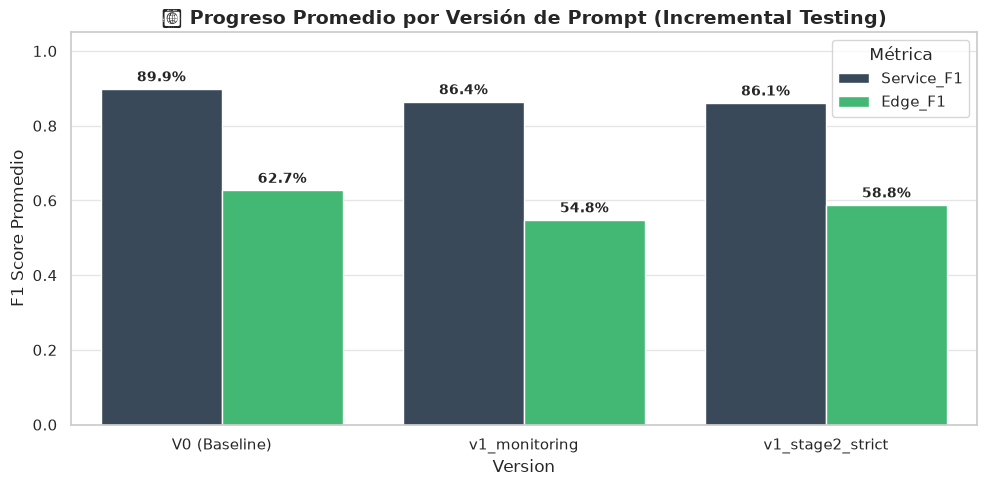

/tmp/ipykernel_51846/4189073809.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], palette="Purples")
/tmp/ipykernel_51846/4189073809.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="Version", y="Service_F1", ax=axes[1], palette="Blues")
/tmp/ipykernel_51846/4189073809.py:74: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


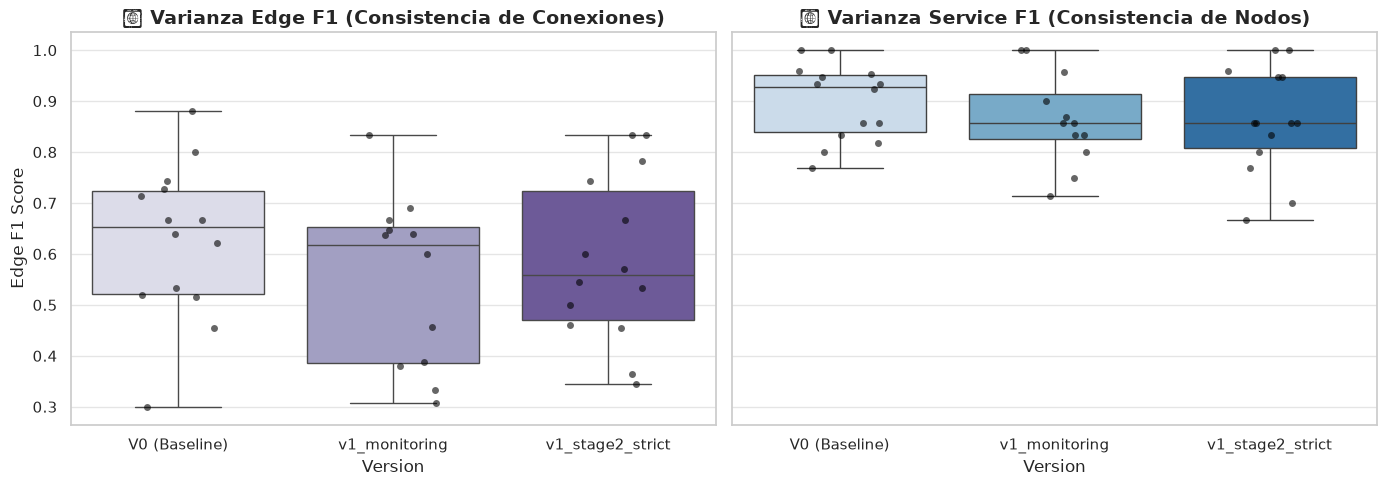

/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_51846/4189073809.py:96: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51846/4189073809.py:96: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3

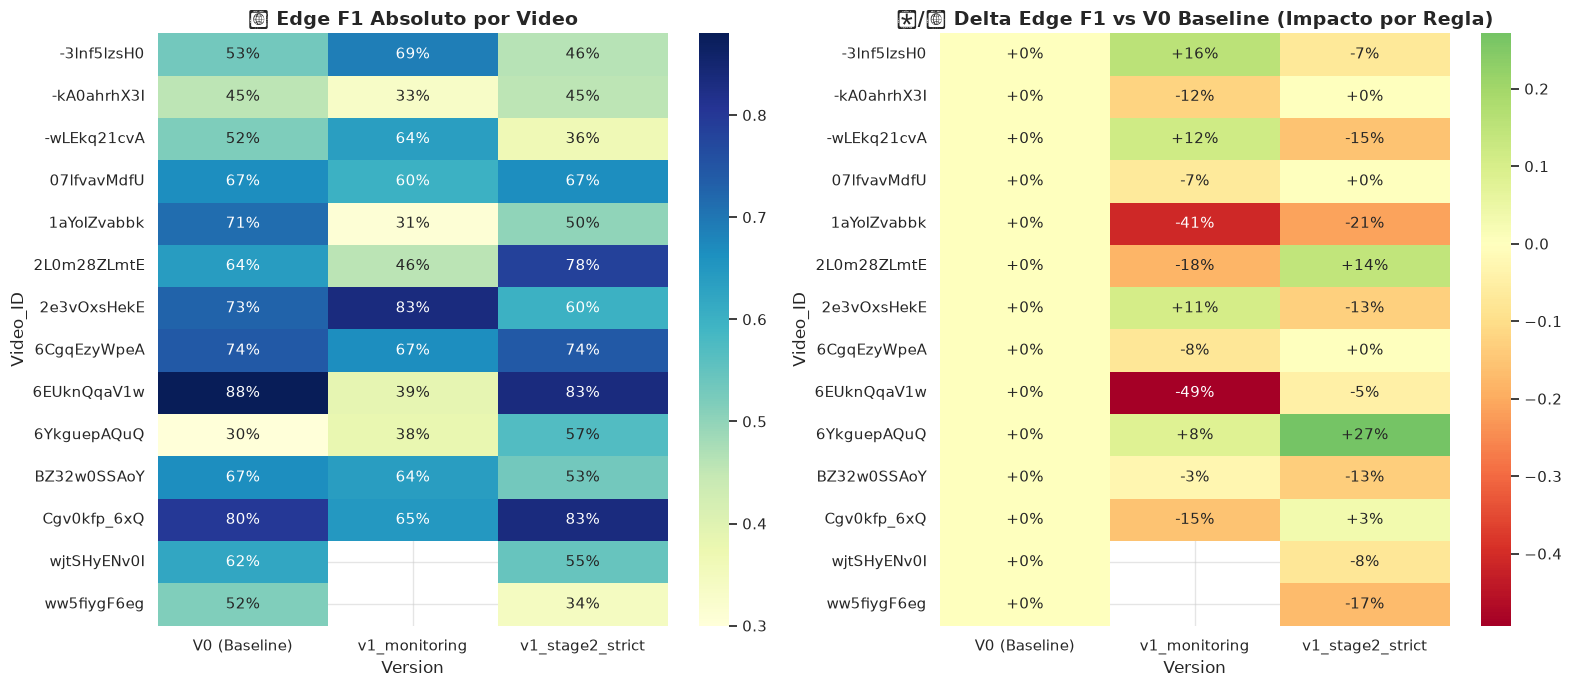

In [16]:
# ==============================================================================
# 📈 GENERACIÓN DE GRÁFICAS DE EVALUACIÓN DE PROMPTS
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

# Cargar todos los archivos batch_results disponibles
summary_files = sorted(list(LAB_DIR.glob("batch_results*.json")))

records = []
for file in summary_files:
    if file.name == "batch_results.json":
        version_name = "V0 (Baseline)"
    else:
        version_name = file.stem.replace("batch_results_", "")
        
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for r in data.get("results", []):
        if r.get("svc_f1") is not None and r.get("edge_f1") is not None:
            records.append({
                "Version": version_name,
                "Video_ID": r["video_id"],
                "Service_F1": r["svc_f1"],
                "Edge_F1": r["edge_f1"],
            })

df_all = pd.DataFrame(records)

if df_all.empty:
    print("⚠ No hay datos de resumen batch disponibles para graficar. Ejecuta el Paso 5 primero.")
else:
    print(f"🔍 Datos cargados exitosamente: {len(df_all)} registros de {df_all['Version'].nunique()} versiones.")
    
    # --------------------------------------------------------------------------
    # 1. BAR CHART: PROGRESO PROMEDIO GLOBAL
    # --------------------------------------------------------------------------
    df_avg = df_all.groupby("Version")[["Service_F1", "Edge_F1"]].mean().reset_index()
    df_avg_melted = df_avg.melt(id_vars="Version", var_name="Métrica", value_name="F1_Score")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = sns.barplot(
        data=df_avg_melted, x="Version", y="F1_Score", hue="Métrica",
        palette=["#34495e", "#2ecc71"], ax=ax
    )
    ax.set_title("📈 Progreso Promedio por Versión de Prompt (Incremental Testing)", fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score Promedio")
    
    for p in bars.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f"{h:.1%}", (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 2. BOXPLOT: VARIANZA Y CONSISTENCIA
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    sns.boxplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], palette="Purples")
    sns.stripplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], color="black", alpha=0.6, jitter=0.2)
    axes[0].set_title("📦 Varianza Edge F1 (Consistencia de Conexiones)", fontweight="bold")
    axes[0].set_ylabel("Edge F1 Score")

    sns.boxplot(data=df_all, x="Version", y="Service_F1", ax=axes[1], palette="Blues")
    sns.stripplot(data=df_all, x="Version", y="Service_F1", ax=axes[1], color="black", alpha=0.6, jitter=0.2)
    axes[1].set_title("📦 Varianza Service F1 (Consistencia de Nodos)", fontweight="bold")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 3. HEATMAP: CELDA A CELDA (VALOR ABSOLUTO Y DELTA VS V0)
    # --------------------------------------------------------------------------
    piv_edge = df_all.pivot(index="Video_ID", columns="Version", values="Edge_F1")
    
    if "V0 (Baseline)" in piv_edge.columns:
        baseline_col = piv_edge["V0 (Baseline)"]
        delta_edge = piv_edge.subtract(baseline_col, axis=0)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Absolute Heatmap
        sns.heatmap(piv_edge, annot=True, fmt=".0%", cmap="YlGnBu", cbar=True, ax=axes[0])
        axes[0].set_title("📊 Edge F1 Absoluto por Video", fontweight="bold")
        
        # Delta Heatmap (Green = Improved, Red = Regressed)
        sns.heatmap(delta_edge, annot=True, fmt="+.0%", cmap="RdYlGn", center=0, cbar=True, ax=axes[1])
        axes[1].set_title("🟢/🔴 Delta Edge F1 vs V0 Baseline (Impacto por Regla)", fontweight="bold")
        
        plt.tight_layout()
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.heatmap(piv_edge, annot=True, fmt=".0%", cmap="YlGnBu", cbar=True, ax=ax)
        ax.set_title("📊 Edge F1 Absoluto por Video y Versión", fontweight="bold")
        plt.tight_layout()
        plt.show()

🔍 Datos cargados exitosamente: 40 registros de 3 versiones.


/tmp/ipykernel_70165/117920987.py:111: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70165/117920987.py:111: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


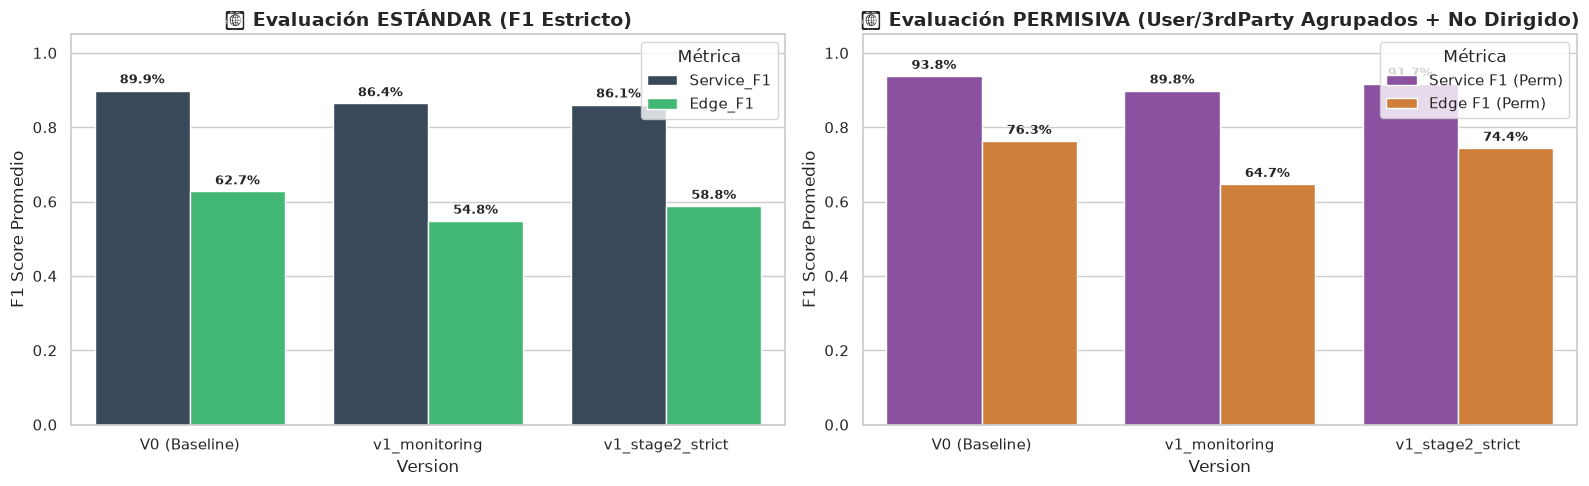

/tmp/ipykernel_70165/117920987.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], palette="Greens")
/tmp/ipykernel_70165/117920987.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="Version", y="Perm_Edge_F1", ax=axes[1], palette="Oranges")
/tmp/ipykernel_70165/117920987.py:130: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


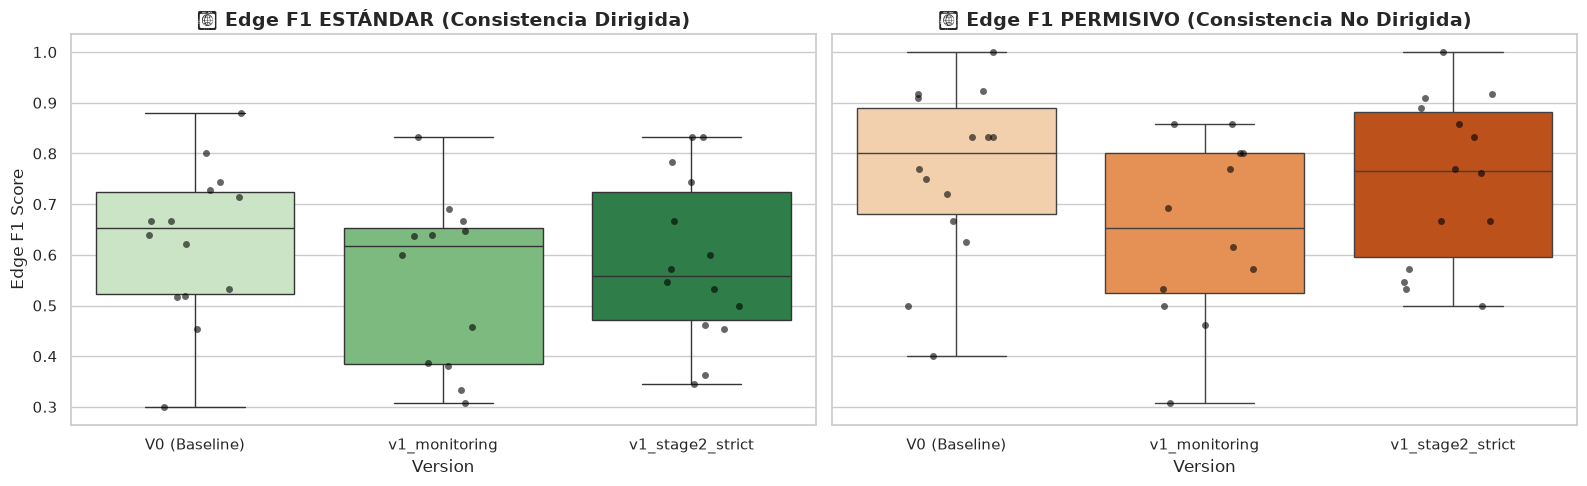

/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_70165/117920987.py:153: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_70165/117920987.py:153: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/stemjara/Projects/AWS-Architecture/.venv/lib/python3.12/site-packages

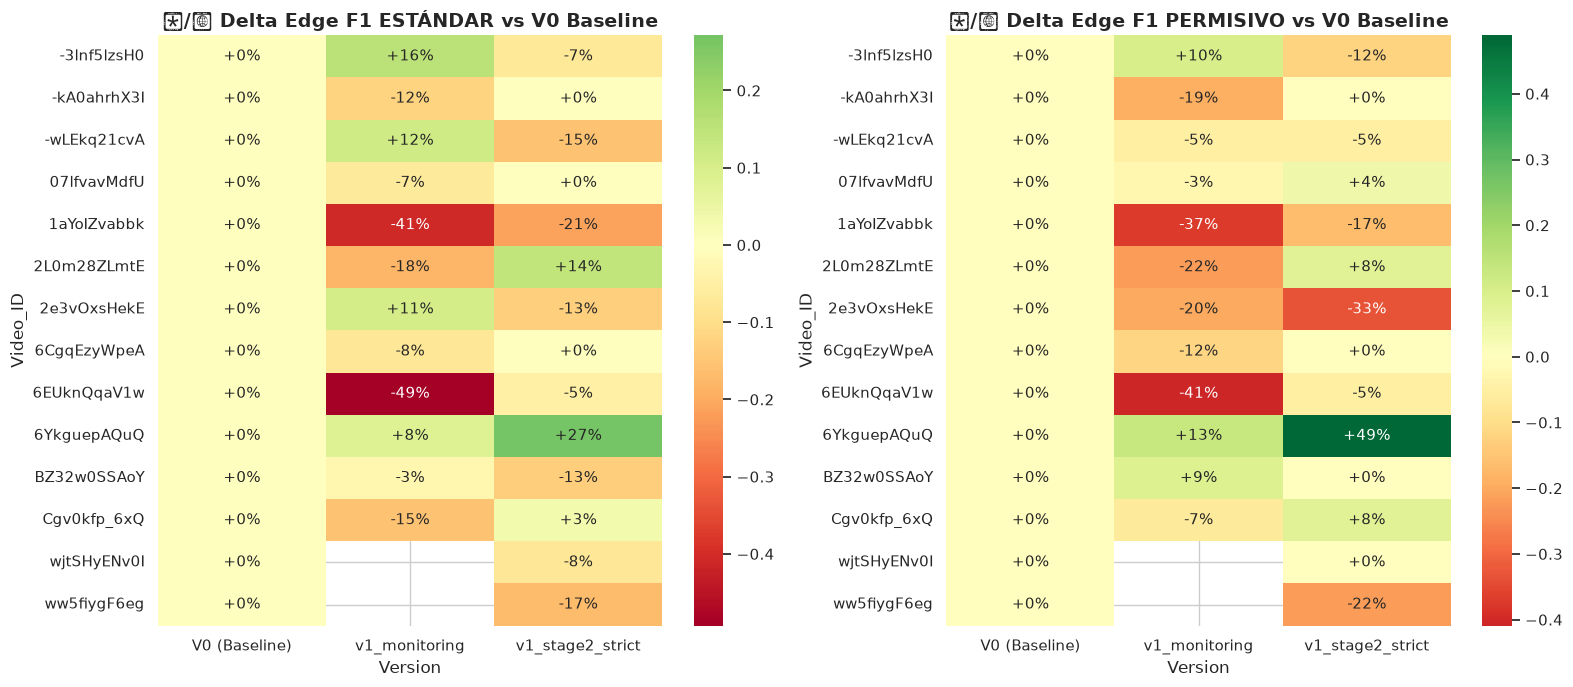

In [4]:
# ==============================================================================
# 📈 GENERACIÓN DE GRÁFICAS DE EVALUACIÓN DE PROMPTS (ESTÁNDAR Y PERMISIVA)
# ==============================================================================
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import sys

# Importar evaluador permisivo desde evaluacion_permisiva.py
if str(LAB_DIR) not in sys.path:
    sys.path.append(str(LAB_DIR))

try:
    from evaluacion_permisiva import evaluate_ultra_permissive_pair
    HAS_PERMISSIVE_EVAL = True
except ImportError:
    HAS_PERMISSIVE_EVAL = False

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14})

# Cargar todos los archivos batch_results disponibles
summary_files = sorted(list(LAB_DIR.glob("batch_results*.json")))

records = []
for file in summary_files:
    if file.name == "batch_results.json":
        version_name = "V0 (Baseline)"
        exp_label = ""
    else:
        version_name = file.stem.replace("batch_results_", "")
        exp_label = version_name
        
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for r in data.get("results", []):
        vid = r.get("video_id")
        if not vid or r.get("status") == "error":
            continue
            
        perm_svc_f1, perm_edge_f1 = None, None
        if HAS_PERMISSIVE_EVAL:
            gt_path = GT_DIR / f"{vid}.graphml"
            suffix = f"_{exp_label}" if exp_label else ""
            gen_path = LAB_WORKSPACE / vid / f"test_graph{suffix}.graphml"
            if not gen_path.exists() and not exp_label:
                gen_path = LAB_WORKSPACE / vid / "test_graph.graphml"

            if gt_path.exists() and gen_path.exists():
                try:
                    g_gt = nx.read_graphml(str(gt_path))
                    g_gen = nx.read_graphml(str(gen_path))
                    res_perm = evaluate_ultra_permissive_pair(g_gen, g_gt, vid)
                    perm_svc_f1 = res_perm["perm_svc_f1"]
                    perm_edge_f1 = res_perm["perm_edge_f1"]
                except Exception:
                    pass
                    
        records.append({
            "Version": version_name,
            "Video_ID": vid,
            "Service_F1": r.get("svc_f1"),
            "Edge_F1": r.get("edge_f1"),
            "Perm_Service_F1": perm_svc_f1,
            "Perm_Edge_F1": perm_edge_f1,
        })

df_all = pd.DataFrame(records)

if df_all.empty:
    print("⚠ No hay datos de resumen batch disponibles para graficar. Ejecuta el Paso 5 primero.")
else:
    print(f"🔍 Datos cargados exitosamente: {len(df_all)} registros de {df_all['Version'].nunique()} versiones.")
    
    # --------------------------------------------------------------------------
    # 1. BAR CHARTS: PROGRESO PROMEDIO (ESTÁNDAR VS PERMISIVA)
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Estándar
    df_avg_std = df_all.groupby("Version")[["Service_F1", "Edge_F1"]].mean().reset_index()
    df_melt_std = df_avg_std.melt(id_vars="Version", var_name="Métrica", value_name="F1_Score")
    bars1 = sns.barplot(data=df_melt_std, x="Version", y="F1_Score", hue="Métrica", palette=["#34495e", "#2ecc71"], ax=axes[0])
    axes[0].set_title("📈 Evaluación ESTÁNDAR (F1 Estricto)", fontweight="bold")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1 Score Promedio")
    for p in bars1.patches:
        h = p.get_height()
        if not np.isnan(h) and h > 0:
            axes[0].annotate(f"{h:.1%}", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')
            
    # Permisivo
    if "Perm_Service_F1" in df_all.columns and df_all["Perm_Service_F1"].notna().any():
        df_avg_perm = df_all.groupby("Version")[["Perm_Service_F1", "Perm_Edge_F1"]].mean().reset_index()
        df_avg_perm.rename(columns={"Perm_Service_F1": "Service F1 (Perm)", "Perm_Edge_F1": "Edge F1 (Perm)"}, inplace=True)
        df_melt_perm = df_avg_perm.melt(id_vars="Version", var_name="Métrica", value_name="F1_Score")
        bars2 = sns.barplot(data=df_melt_perm, x="Version", y="F1_Score", hue="Métrica", palette=["#8e44ad", "#e67e22"], ax=axes[1])
        axes[1].set_title("🔓 Evaluación PERMISIVA (User/3rdParty Agrupados + No Dirigido)", fontweight="bold")
        axes[1].set_ylim(0, 1.05)
        axes[1].set_ylabel("F1 Score Promedio")
        for p in bars2.patches:
            h = p.get_height()
            if not np.isnan(h) and h > 0:
                axes[1].annotate(f"{h:.1%}", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 2. BOXPLOTS: VARIANZA Y CONSISTENCIA (ESTÁNDAR VS PERMISIVA)
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    sns.boxplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], palette="Greens")
    sns.stripplot(data=df_all, x="Version", y="Edge_F1", ax=axes[0], color="black", alpha=0.6, jitter=0.2)
    axes[0].set_title("📦 Edge F1 ESTÁNDAR (Consistencia Dirigida)", fontweight="bold")
    axes[0].set_ylabel("Edge F1 Score")

    if "Perm_Edge_F1" in df_all.columns and df_all["Perm_Edge_F1"].notna().any():
        sns.boxplot(data=df_all, x="Version", y="Perm_Edge_F1", ax=axes[1], palette="Oranges")
        sns.stripplot(data=df_all, x="Version", y="Perm_Edge_F1", ax=axes[1], color="black", alpha=0.6, jitter=0.2)
        axes[1].set_title("📦 Edge F1 PERMISIVO (Consistencia No Dirigida)", fontweight="bold")
        axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # 3. HEATMAPS: DELTAS VS V0 BASELINE (ESTÁNDAR VS PERMISIVA)
    # --------------------------------------------------------------------------
    piv_std = df_all.pivot(index="Video_ID", columns="Version", values="Edge_F1")
    piv_perm = df_all.pivot(index="Video_ID", columns="Version", values="Perm_Edge_F1") if "Perm_Edge_F1" in df_all.columns else None
    
    if "V0 (Baseline)" in piv_std.columns:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Delta Estándar
        delta_std = piv_std.subtract(piv_std["V0 (Baseline)"], axis=0)
        sns.heatmap(delta_std, annot=True, fmt="+.0%", cmap="RdYlGn", center=0, cbar=True, ax=axes[0])
        axes[0].set_title("🟢/🔴 Delta Edge F1 ESTÁNDAR vs V0 Baseline", fontweight="bold")
        
        # Delta Permisivo
        if piv_perm is not None and "V0 (Baseline)" in piv_perm.columns:
            delta_perm = piv_perm.subtract(piv_perm["V0 (Baseline)"], axis=0)
            sns.heatmap(delta_perm, annot=True, fmt="+.0%", cmap="RdYlGn", center=0, cbar=True, ax=axes[1])
            axes[1].set_title("🟢/🔴 Delta Edge F1 PERMISIVO vs V0 Baseline", fontweight="bold")
            
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        sns.heatmap(piv_std, annot=True, fmt=".0%", cmap="YlGnBu", cbar=True, ax=axes[0])
        axes[0].set_title("📊 Edge F1 ESTÁNDAR Absoluto por Video", fontweight="bold")
        if piv_perm is not None:
            sns.heatmap(piv_perm, annot=True, fmt=".0%", cmap="YlOrBr", cbar=True, ax=axes[1])
            axes[1].set_title("📊 Edge F1 PERMISIVO Absoluto por Video", fontweight="bold")
        plt.tight_layout()
        plt.show()
